# Conflict RSS Map — Complete Jupyter Notebook

Run the cells from top to bottom.

This notebook will:
- install/import required packages
- fetch RSS feeds
- filter conflict-related headlines
- estimate locations from text
- geocode locations with Nominatim
- cluster incidents with DBSCAN
- build an interactive Folium map
- show a table and simple charts
- save the map as HTML


In [25]:
# Install if needed
# Uncomment if packages are missing
!pip install folium geopy feedparser scikit-learn numpy pandas matplotlib


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## 1) Imports

In [23]:
import re
import time
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import feedparser
import folium
import matplotlib.pyplot as plt

from folium.plugins import MarkerCluster, HeatMap
from geopy.geocoders import Nominatim
from sklearn.cluster import DBSCAN

try:
    from IPython.display import display, clear_output
except ImportError:
    display = print
    def clear_output(wait=True):
        pass


## 2) Configuration

In [24]:
RSS_FEEDS = [
    "https://feeds.reuters.com/reuters/worldNews",
    "https://www.aljazeera.com/xml/rss/all.xml",
    "https://rss.nytimes.com/services/xml/rss/nyt/World.xml",
]

MAP_CENTER = [32.5, 53.5]
MAP_ZOOM = 5
MAX_ENTRIES_PER_FEED = 20
HTML_FILE = "conflict_rss_map.html"

CONFLICT_TERMS = [
    "iran", "israel", "strike", "missile", "attack", "drone",
    "explosion", "military", "bomb", "rocket", "conflict",
    "tehran", "natanz", "fordow", "gaza", "lebanon", "syria", "iraq"
]

HIGH_SEVERITY_WORDS = [
    "missile", "strike", "bomb", "attack", "drone", "explosion",
    "killed", "dead", "casualties", "military", "rocket"
]

MEDIUM_SEVERITY_WORDS = [
    "warning", "tension", "troops", "sanction", "conflict", "clash"
]

PLACE_HINTS = {
    "Tehran": "Tehran, Iran",
    "Isfahan": "Isfahan, Iran",
    "Shiraz": "Shiraz, Iran",
    "Tabriz": "Tabriz, Iran",
    "Mashhad": "Mashhad, Iran",
    "Qom": "Qom, Iran",
    "Karaj": "Karaj, Iran",
    "Ahvaz": "Ahvaz, Iran",
    "Bandar Abbas": "Bandar Abbas, Iran",
    "Bushehr": "Bushehr, Iran",
    "Natanz": "Natanz, Iran",
    "Fordow": "Fordow, Iran",
    "Kermanshah": "Kermanshah, Iran",
    "Khuzestan": "Khuzestan, Iran",
    "Iran": "Iran",
    "Tel Aviv": "Tel Aviv, Israel",
    "Jerusalem": "Jerusalem, Israel",
    "Israel": "Jerusalem, Israel",
    "Gaza": "Gaza",
    "Lebanon": "Beirut, Lebanon",
    "Beirut": "Beirut, Lebanon",
    "Syria": "Damascus, Syria",
    "Damascus": "Damascus, Syria",
    "Iraq": "Baghdad, Iraq",
    "Baghdad": "Baghdad, Iraq",
    "Yemen": "Sanaa, Yemen",
    "Sanaa": "Sanaa, Yemen",
    "Washington": "Washington, DC, USA",
    "Pentagon": "Washington, DC, USA",
}


## 3) Core helpers

In [4]:
geolocator = Nominatim(user_agent="conflict_rss_map")
geo_cache = {}

def clean_text(text):
    text = re.sub(r"<[^>]+>", " ", text or "")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def geocode_location(loc):
    if loc in geo_cache:
        return geo_cache[loc]
    try:
        point = geolocator.geocode(loc, timeout=10)
        if point:
            geo_cache[loc] = {"lat": point.latitude, "lon": point.longitude}
            return geo_cache[loc]
    except Exception:
        pass
    return None

def parse_time(entry):
    for field in ["published_parsed", "updated_parsed"]:
        parsed = getattr(entry, field, None)
        if parsed:
            try:
                return datetime.fromtimestamp(time.mktime(parsed), tz=timezone.utc)
            except Exception:
                pass
    return datetime.now(timezone.utc)

def is_conflict_related(text):
    t = text.lower()
    return any(term in t for term in CONFLICT_TERMS)

def extract_location(text):
    t = text.lower()
    matches = []
    for hint, canonical in PLACE_HINTS.items():
        if hint.lower() in t:
            matches.append((hint, canonical))
    matches.sort(key=lambda x: len(x[0]), reverse=True)
    if matches:
        return matches[0][1]
    return "Iran"

def severity_score(text):
    t = text.lower()
    score = 3
    for word in HIGH_SEVERITY_WORDS:
        if word in t:
            score += 4
    for word in MEDIUM_SEVERITY_WORDS:
        if word in t:
            score += 2
    score += min(len(text.split()) // 10, 4)
    return min(score, 15)

def detect_side(text):
    t = text.lower()
    if "iran" in t and ("israel" in t or "u.s." in t or "us " in t or "american" in t):
        return "Mixed"
    if "iran" in t:
        return "Iran"
    if "israel" in t:
        return "Israel"
    if "u.s." in t or "us " in t or "american" in t or "pentagon" in t or "washington" in t:
        return "US"
    return "Other"

def deduplicate_items(items):
    seen = set()
    out = []
    for item in items:
        key = (
            item["title"].strip().lower(),
            round(item["lat"], 2),
            round(item["lon"], 2),
        )
        if key not in seen:
            seen.add(key)
            out.append(item)
    return out

def color_for_side(side):
    return {
        "Iran": "red",
        "Israel": "blue",
        "US": "green",
        "Mixed": "purple",
    }.get(side, "gray")


## 4) RSS parsing

In [5]:
def parse_rss():
    incidents = []

    for feed_url in RSS_FEEDS:
        try:
            feed = feedparser.parse(feed_url)
        except Exception:
            continue

        source_title = clean_text(feed.get("feed", {}).get("title", feed_url))

        for entry in feed.entries[:MAX_ENTRIES_PER_FEED]:
            title = clean_text(getattr(entry, "title", ""))
            summary = clean_text(getattr(entry, "summary", ""))
            combined = f"{title} {summary}".strip()

            if not combined or not is_conflict_related(combined):
                continue

            if "tehran" in title.lower():
                loc = "Tehran, Iran"
            elif "isfahan" in title.lower():
                loc = "Isfahan, Iran"
            elif "shiraz" in title.lower():
                loc = "Shiraz, Iran"
            else:
                loc = extract_location(combined)

            geo = geocode_location(loc)
            time.sleep(1)  # polite delay for Nominatim

            if not geo:
                continue

            incidents.append({
                "title": title,
                "summary": summary,
                "source": source_title,
                "link": getattr(entry, "link", ""),
                "published": parse_time(entry),
                "lat": geo["lat"],
                "lon": geo["lon"],
                "location_name": loc,
                "intensity": 5 + len(title.split()),
                "severity": severity_score(combined),
                "side": detect_side(combined),
            })

    incidents = deduplicate_items(incidents)
    incidents.sort(key=lambda x: x["published"], reverse=True)
    return incidents


## 5) Clustering, table, and map

In [21]:
def apply_clustering(incidents):
    if not incidents:
        return incidents

    coords = np.array([[x["lat"], x["lon"]] for x in incidents])
    if len(coords) >= 2:
        labels = DBSCAN(eps=1.5, min_samples=2).fit(coords).labels_
    else:
        labels = np.array([-1])

    for i, label in enumerate(labels):
        incidents[i]["cluster"] = int(label)
    return incidents

def incidents_to_dataframe(incidents):
    if not incidents:
        return pd.DataFrame(columns=[
            "published", "location_name", "side", "intensity",
            "severity", "cluster", "source", "title", "link"
        ])

    return pd.DataFrame([{
        "published": x["published"].strftime("%Y-%m-%d %H:%M:%S UTC"),
        "location_name": x["location_name"],
        "side": x["side"],
        "intensity": x["intensity"],
        "severity": x["severity"],
        "cluster": x.get("cluster", -1),
        "source": x["source"],
        "title": x["title"],
        "link": x["link"],
    } for x in incidents])

def build_map(incidents):
    m = folium.Map(location=MAP_CENTER, zoom_start=MAP_ZOOM, tiles="CartoDB positron")
    marker_cluster = MarkerCluster().add_to(m)

    for item in incidents:
        folium.CircleMarker(
            location=[item["lat"], item["lon"]],
            radius=max(4, min(item["severity"], 15)),
            color=color_for_side(item["side"]),
            fill=True,
            fill_opacity=0.65,
            popup=folium.Popup(
                f"<b>{item['title']}</b><br>"
                f"Location: {item['location_name']}<br>"
                f"Side: {item['side']}<br>"
                f"Severity: {item['severity']}<br>"
                f"Cluster: {item.get('cluster', -1)}<br>"
                f"Source: {item['source']}",
                max_width=450
            ),
            tooltip=f"{item['location_name']} | Sev {item['severity']}"
        ).add_to(marker_cluster)

    if incidents:
        HeatMap([[x["lat"], x["lon"], x["severity"]] for x in incidents], radius=35, blur=20).add_to(m)

    return m


## 6) Charts

In [18]:
def plot_side_counts(df):
    if df.empty:
        print("No data to plot.")
        return
    counts = df["side"].value_counts()
    plt.figure(figsize=(8, 4.5))
    counts.plot(kind="bar")
    plt.title("Incidents by side")
    plt.xlabel("Side")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def plot_source_counts(df):
    if df.empty:
        print("No data to plot.")
        return
    counts = df["source"].value_counts()
    plt.figure(figsize=(10, 4.5))
    counts.plot(kind="bar")
    plt.title("Incidents by source")
    plt.xlabel("Source")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

def plot_severity_by_source(df):
    if df.empty:
        print("No data to plot.")
        return
    temp = df.groupby("source", as_index=False)["severity"].mean().sort_values("severity", ascending=False)
    plt.figure(figsize=(10, 4.5))
    plt.bar(temp["source"], temp["severity"])
    plt.title("Average severity by source")
    plt.xlabel("Source")
    plt.ylabel("Average severity")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 7) Run once

In [19]:
def run_once():
    incidents = apply_clustering(parse_rss())
    df = incidents_to_dataframe(incidents)
    m = build_map(incidents)
    m.save(HTML_FILE)
    print(f"Mapped incidents: {len(incidents)}")
    print(f"Saved map to: {HTML_FILE}")
    return incidents, df, m

incidents, df, m = run_once()
display(df.head(20))
m


Mapped incidents: 25
Saved map to: conflict_rss_map.html


,published,location_name,side,intensity,severity,cluster,source,title,link
0,2026-03-07 18:28:42 UTC,Iran,Other,19,14,0,NYT > World News,Mideast Fighting: Live Updates: Strikes Launch...,https://www.nytimes.com/live/2026/03/07/world/...
1,2026-03-07 18:06:20 UTC,Iran,Mixed,19,10,0,NYT > World News,Recent U.S. Assessment Found an Attack on Iran...,https://www.nytimes.com/2026/03/07/world/middl...
2,2026-03-07 17:56:30 UTC,Iran,US,15,9,0,"Al Jazeera – Breaking News, World News and Vid...","‘They’re cancer’: Trump threatens cartels, Cub...",https://www.aljazeera.com/news/2026/3/7/theyre...
3,2026-03-07 17:48:41 UTC,"Jerusalem, Israel",Mixed,19,15,1,NYT > World News,Pakistan Praised Trump. Now It Risks Being Cau...,https://www.nytimes.com/2026/03/07/world/asia/...
4,2026-03-07 17:46:29 UTC,Iran,US,18,10,0,NYT > World News,Defense Without U.S. Help Is a Live Topic for ...,https://www.nytimes.com/2026/03/06/world/canad...
5,2026-03-07 17:24:09 UTC,"Beirut, Lebanon",Israel,14,5,2,"Al Jazeera – Breaking News, World News and Vid...",Israel launches raid in Lebanon searching for ...,https://www.aljazeera.com/video/newsfeed/2026/...
6,2026-03-07 17:02:38 UTC,Iran,Iran,15,14,0,NYT > World News,Iranian President’s Apology to Neighboring Gul...,https://www.nytimes.com/2026/03/07/world/middl...
7,2026-03-07 16:14:23 UTC,Iran,Other,12,15,0,NYT > World News,Russia Attacks Kharkiv and Kyiv in Ukraine,https://www.nytimes.com/2026/03/07/world/europ...
8,2026-03-07 16:10:29 UTC,Iran,Other,17,10,0,NYT > World News,"Ian Huntley, Whose Murder of Schoolgirls Appal...",https://www.nytimes.com/2026/03/07/world/europ...
9,2026-03-07 15:56:01 UTC,Gaza,Other,18,5,-1,"Al Jazeera – Breaking News, World News and Vid...",What people in Gaza are saying about the closu...,https://www.aljazeera.com/video/newsfeed/2026/...


## 8) Optional charts

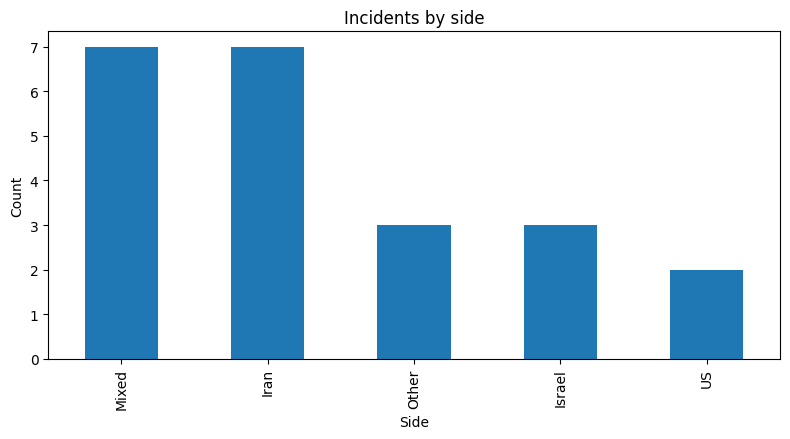

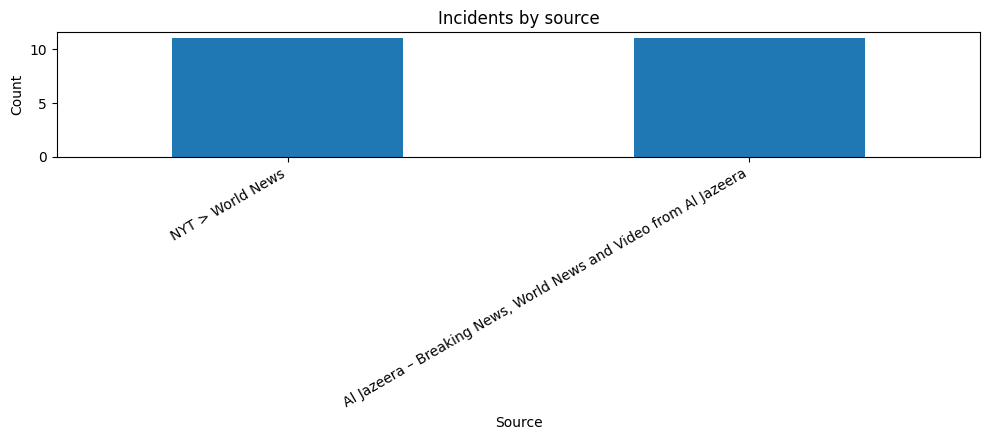

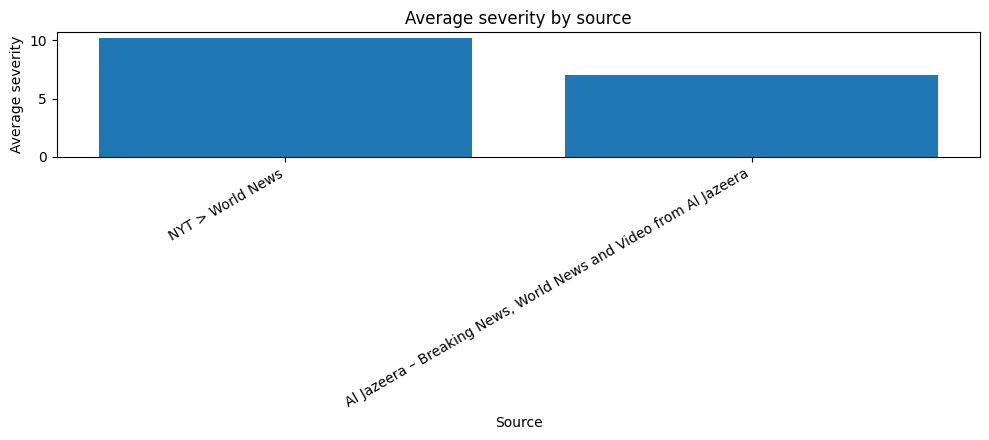

In [14]:
plot_side_counts(df)
plot_source_counts(df)
plot_severity_by_source(df)


## 9) Optional auto-refresh

In [17]:
def auto_refresh_loop(refresh_seconds=300, iterations=3):
    for i in range(iterations):
        clear_output(wait=True)
        print(f"Refresh cycle {i+1}/{iterations} at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        incidents, df, m = run_once()
        display(df.head(20))
        display(m)
        if i < iterations - 1:
            print(f"Sleeping {refresh_seconds} seconds...")
            time.sleep(refresh_seconds)

# Example:
# auto_refresh_loop(refresh_seconds=300, iterations=3)
